In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
np.float = np.float64
import sys
sys.path.append("/n/home07/yitians/fermi/NPTFit/NPTFit")

import healpy as hp
import pickle
from tqdm import tqdm

from NPTFit import npll

from nptfit_func import *

sys.path.append("..")
from utils import create_mask as cm
from models.templates import NFWTemplate, LorimerDiskTemplate
from models.psf import KingPSF
from utils.utils import find_max_point

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

In [2]:
# mask
nside = 128
band_mask_range = 2.
r_outer = 25.
mask_ps = hp.ud_grade(np.load(f"../data/mask_3fgl_0p8deg.npy"), nside_out=nside) > 0
mask_roi = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=band_mask_range, mask_ring=True, inner=0, outer=r_outer, custom_mask=mask_ps)
mask_plane = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=25,)
normalization_mask = mask_plane

# temp
nfw_template = NFWTemplate(nside=nside)
disk_template = LorimerDiskTemplate(nside=nside)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [3]:
# psf
kp = KingPSF()
f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = kp.psf_fermi_r)

## scan 2D

In [4]:
truth_dict = pickle.load(open('../outputs/justSps/truth.p', 'rb'))

temp_ps_gce = nfw_template.get_NFW2_template(gamma=truth_dict['gamma_ps'])
zs = truth_dict['zs']
C = truth_dict['C']
temp_ps_dsk = disk_template.get_template(zs=zs, C=C)

# S over A dsk
s_ary = np.logspace(-1., 2., 100)
vd = truth_dict
theta_tmp = np.array([1., vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['lambdas_dsk'] * vd['sb1_dsk']])
dnds_ary = dnds(s_ary, theta_tmp)
Sps_over_A_dsk = np.mean(temp_ps_dsk[~normalization_mask]) * np.trapz(s_ary * dnds_ary, s_ary)

# S over A gce
s_ary = np.logspace(-1., 2., 100)
vd = truth_dict
theta_tmp = np.array([1., vd['n1_gce'], vd['n2_gce'], vd['n3_gce'], vd['sb1_gce'], vd['lambdas_gce'] * vd['sb1_gce']])
dnds_ary = dnds(s_ary, theta_tmp)
Sps_over_A_gce = np.mean(temp_ps_dsk[~normalization_mask]) * np.trapz(s_ary * dnds_ary, s_ary)

In [13]:
Sps_dsk_s = np.linspace(0.5, 1.5, 50)
ll_ss = []
counts_arr = []

mask = normalization_mask

pt_sum_compressed = np.full_like(temp_ps_dsk[~mask], 1e-10, dtype=np.float64)
npt_compressed = [
    np.array(temp_ps_dsk[~mask], dtype=np.float64),
    np.array(temp_ps_gce[~mask], dtype=np.float64),
]

for i_data in tqdm(range(100)):
    ll_s = []
    fermi_data = np.load(f'../outputs/justSps/counts_{i_data}.npy')[~mask].astype(np.int32)
    counts_arr.append(np.sum(fermi_data))
    for i, Sps_dsk in enumerate(Sps_dsk_s):
        A_dsk = Sps_dsk / Sps_over_A_dsk
        A_gce = vd['Sps_gce'] / Sps_over_A_gce
        theta = np.array([
            [A_dsk, vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['sb1_dsk']*vd['lambdas_dsk']],
            [A_gce, vd['n1_gce'], vd['n2_gce'], vd['n3_gce'], vd['sb1_gce'], vd['sb1_gce']*vd['lambdas_gce']],
        ], dtype=np.float64)
        ll = npll.log_like(pt_sum_compressed, theta, f_ary, df_rho_div_f_ary, npt_compressed, fermi_data)
        ll_s.append(ll)
    ll_ss.append(ll_s)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:42<00:00,  1.63s/it]


[Text(0.5, 1.0, 'Simulated map with Sps_gce=2, Sps_dsk=1, color~counts'),
 Text(0.5, 0, 'Sps_dsk'),
 Text(0, 0.5, 'll')]

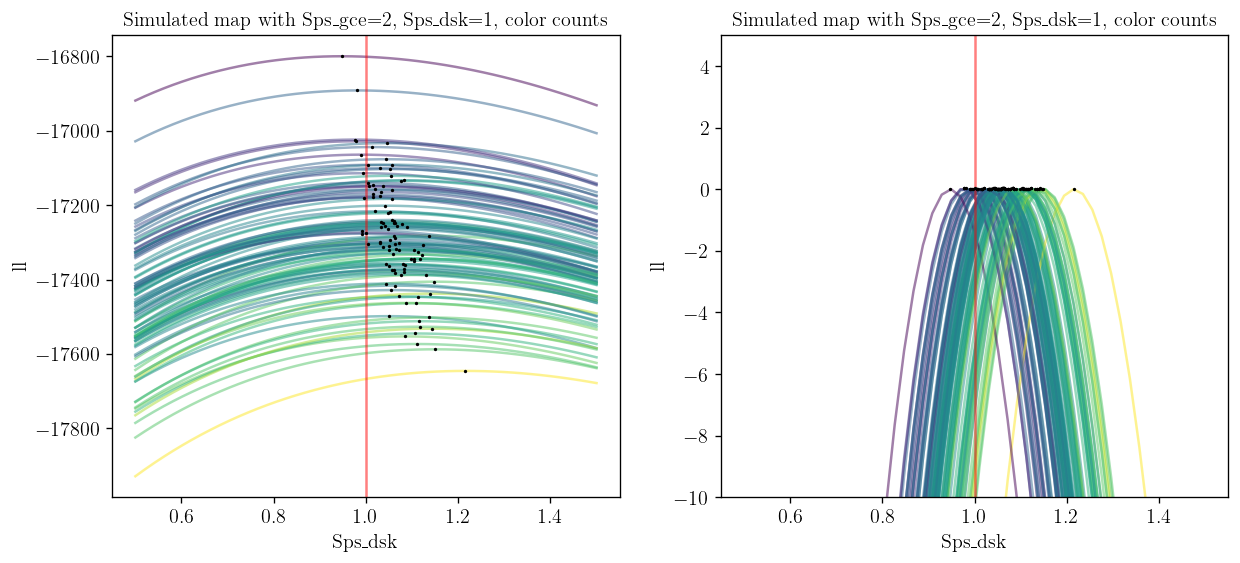

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

max_x_s = []
max_y_s = []

for i in range(100):
    ax = axs[0]
    color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
    color = cms['viridis'](color_x)
    rll = ll_ss[i]
    ax.plot(Sps_dsk_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_dsk_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)
    max_x_s.append(max_x)
    max_y_s.append(max_y)

    ax = axs[1]
    rll = ll_ss[i] - np.max(ll_ss[i])
    ax.plot(Sps_dsk_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_dsk_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)

ax = axs[0]
ax.axvline(truth_dict['Sps_dsk'], color='r', ls='-', alpha=0.5)
ax.set(title="Simulated map with Sps_gce=2, Sps_dsk=1, color~counts", xlabel="Sps_dsk", ylabel='ll')
ax = axs[1]
ax.axvline(truth_dict['Sps_dsk'], color='r', ls='-', alpha=0.5)
ax.set(ylim=(-10, 5))
ax.set(title="Simulated map with Sps_gce=2, Sps_dsk=1, color~counts", xlabel="Sps_dsk", ylabel='ll')

In [11]:
Sps_gce_s = np.linspace(1.5, 2.5, 50)
ll_ss = []
counts_arr = []

mask = normalization_mask

pt_sum_compressed = np.full_like(temp_ps_dsk[~mask], 1e-10, dtype=np.float64)
npt_compressed = [
    np.array(temp_ps_dsk[~mask], dtype=np.float64),
    np.array(temp_ps_gce[~mask], dtype=np.float64),
]

for i_data in tqdm(range(100)):
    ll_s = []
    fermi_data = np.load(f'../outputs/justSps/counts_{i_data}.npy')[~mask].astype(np.int32)
    counts_arr.append(np.sum(fermi_data))
    for i, Sps_gce in enumerate(Sps_gce_s):
        A_dsk = vd['Sps_dsk'] / Sps_over_A_dsk
        A_gce = Sps_gce / Sps_over_A_gce
        theta = np.array([
            [A_dsk, vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['sb1_dsk']*vd['lambdas_dsk']],
            [A_gce, vd['n1_gce'], vd['n2_gce'], vd['n3_gce'], vd['sb1_gce'], vd['sb1_gce']*vd['lambdas_gce']],
        ], dtype=np.float64)
        ll = npll.log_like(pt_sum_compressed, theta, f_ary, df_rho_div_f_ary, npt_compressed, fermi_data)
        ll_s.append(ll)
    ll_ss.append(ll_s)

100%|██████████| 100/100 [02:45<00:00,  1.66s/it]


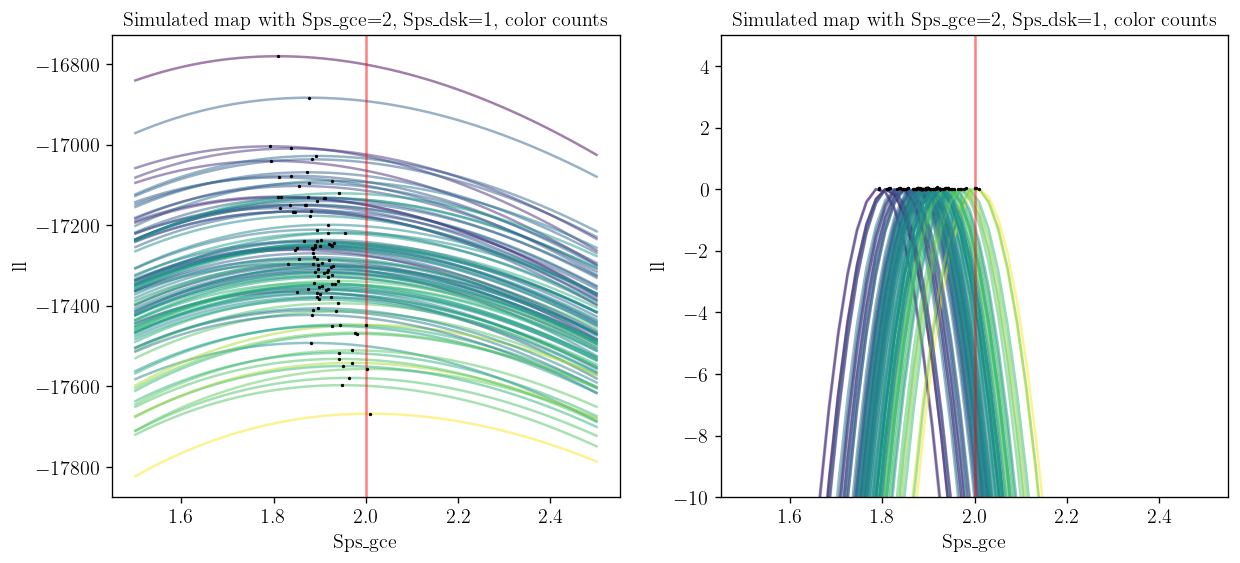

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

max_x_s = []
max_y_s = []

for i in range(100):
    ax = axs[0]
    color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
    color = cms['viridis'](color_x)
    rll = ll_ss[i]
    ax.plot(Sps_gce_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_gce_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)
    max_x_s.append(max_x)
    max_y_s.append(max_y)

    ax = axs[1]
    rll = ll_ss[i] - np.max(ll_ss[i])
    ax.plot(Sps_gce_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_gce_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)

ax = axs[0]
ax.axvline(truth_dict['Sps_gce'], color='r', ls='-', alpha=0.5)
ax.set(title="Simulated map with Sps_gce=2, Sps_dsk=1, color~counts", xlabel="Sps_gce", ylabel='ll')

ax = axs[1]
ax.axvline(truth_dict['Sps_gce'], color='r', ls='-', alpha=0.5)
ax.set(ylim=(-10, 5))
ax.set(title="Simulated map with Sps_gce=2, Sps_dsk=1, color~counts", xlabel="Sps_gce", ylabel='ll');

## scan 1D

In [ ]:
truth_dict = pickle.load(open('../outputs/Sps_dsk/truth.p', 'rb'))

In [11]:
# S over A
s_ary = np.logspace(-1., 2., 100)
vd = truth_dict
theta_tmp = np.array([1., vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['lambdas_dsk'] * vd['sb1_dsk']])
dnds_ary = dnds(s_ary, theta_tmp)
Sps_over_A = np.mean(temp_ps_dsk[~normalization_mask]) * np.trapz(s_ary * dnds_ary, s_ary)

8.838435e-06 0.03535374


In [23]:
# setup
pt_sum_compressed = np.full_like(temp_ps_dsk[~normalization_mask], 1e-10, dtype=np.float64)
theta = np.array([0.01, vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['sb1_dsk']*vd['lambdas_dsk']], dtype=np.float64)
kp = KingPSF()
psf_r_func = lambda r: kp.psf_fermi_r(r)
f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = psf_r_func)
npt_compressed = [np.array(temp_ps_dsk[~normalization_mask], dtype=np.float64)]
fermi_data = np.load('../outputs/Sps_dsk/counts_0.npy')[~normalization_mask].astype(np.int32)

In [36]:
Sps_s = np.linspace(0.8, 1.2, 100)
ll_ss = []

for i_data in tqdm(range(100)):
    ll_s = []
    fermi_data = fermi_data = np.load(f'../outputs/Sps_dsk/counts_{i_data}.npy')[~normalization_mask].astype(np.int32)
    for i, Sps in enumerate(Sps_s):
        A = Sps / Sps_over_A
        theta = np.array([A, vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['sb1_dsk']*vd['lambdas_dsk']], dtype=np.float64)
        ll = npll.log_like(pt_sum_compressed, [theta], f_ary, df_rho_div_f_ary, npt_compressed, fermi_data)
        ll_s.append(ll)
    ll_ss.append(ll_s)

100%|██████████| 100/100 [02:28<00:00,  1.49s/it]


[(-30.0, 5.0)]

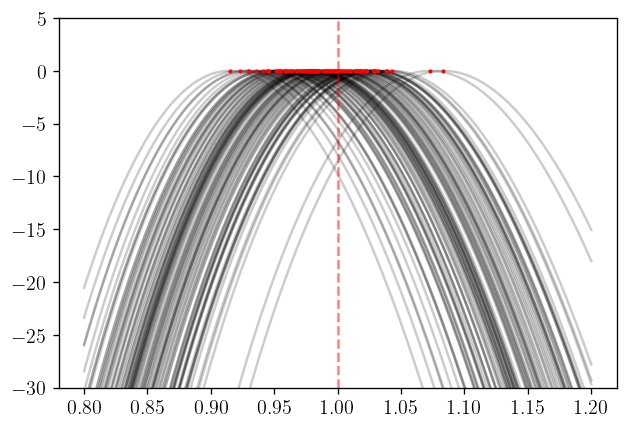

In [48]:
fig, ax = plt.subplots()

max_x_s = []
max_y_s = []

for i in range(100):
    rll = ll_ss[i] - np.max(ll_ss[i])
    ax.plot(Sps_s, rll, color='k', alpha=0.2)
    max_x, max_y = find_max_point(Sps_s, rll)
    max_x_s.append(max_x)
    max_y_s.append(max_y)
ax.scatter(max_x_s, max_y_s, c='r', s=2, zorder=10)
ax.axvline(truth_dict['Sps_dsk'], color='r', ls='--', alpha=0.5)
ax.set(ylim=(-30, 5))

In [51]:
np.mean(max_x_s), np.std(max_x_s)

(0.9884043052439351, 0.0307520465287156)